In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# For data processing
from mlip.data import BuilderMode, ExtxyzReader, GraphDatasetBuilder

# For model
from mlip.models import ForceField, Visnet, Nequip

# For loss function
from mlip.models.loss import MSELoss
from mlip.models.model_io import load_model_from_zip, save_model_to_zip
from mlip.models.params_loading import load_parameters_from_checkpoint

# For optimizer
# For training
from mlip.training import TrainingLoop, get_default_mlip_optimizer
from mlip.typing.properties import Properties


import logging
import sys

mlip_logger = logging.getLogger("mlip")
mlip_logger.setLevel(logging.INFO)

if not mlip_logger.handlers:
    handler = logging.StreamHandler(sys.stdout)
    handler.setFormatter(
        logging.Formatter("%(levelname)s - %(message)s")
    )
    mlip_logger.addHandler(handler)

mlip_logger.propagate = False

In [14]:
loaded_force_field = load_model_from_zip(
    Nequip, "/Users/alirezahosseini/Desktop/Other Projects/MLIP/final_model_4A.zip", required_properties=Properties(stress=True)
)

print("Dataset info:", loaded_force_field.dataset_info)

Dataset info: Atomic Energies: {'H': -6.680310433885136, 'O': -3.3401552169425424, 'Pt': -5.010232825413734}, Total Charges Supported: None, Graph Cutoff (Å): 4.0, Long Range Cutoff (Å): None, Avg Num Neighbors: 21.255742521367523, Avg R Min (Å): 0.9316328958920472, Scaling Mean: 0.0, Scaling Stdev: 1.0, Atomic Energies Removed: False


In [16]:
from pathlib import Path
from mlip.data import ExtxyzReader

data_directory = Path("pt_water_split")

train_path = data_directory / "train.extxyz"
validation_path = data_directory / "validation.extxyz"
test_path = data_directory / "test.extxyz"

readers = {
    "train": ExtxyzReader(train_path),
    "validation": ExtxyzReader(validation_path),
    "test": ExtxyzReader(test_path),
}

In [18]:
from dataclasses import replace
from ase.io import read

import jax
import jax.numpy as jnp
from mlip.inference import run_batched_inference


test_structures = read(
    test_path,
    index=":",
)

print(
    "Number of test configurations:",
    len(test_structures),
)


# Convert every parameter leaf back to a JAX array
jax_params = jax.tree.map(
    jnp.asarray,
    loaded_force_field.params,
)

optimized_force_field = replace(
    loaded_force_field,
    params=jax_params,
)

# Run predictions
predictions = run_batched_inference(
    structures=test_structures,
    force_field=optimized_force_field,
    batch_size=5,
)

print("Number of predictions:", len(predictions))

Number of test configurations: 790


graph creation:   0%|          | 0/790 [00:00<?, ?it/s]

INFO - The batching parameter max_n_node has been computed to be 144.
INFO - The batching parameter max_n_edge has been computed to be 1584.
INFO - Graphs preparation done. Now running inference on 790 structure(s) in 159 batches...
INFO - Batch 1 completed. Took 2.029 seconds.
INFO - Batch 2 completed. Took 0.427 seconds.
INFO - Batch 3 completed. Took 0.427 seconds.
INFO - Batch 4 completed. Took 0.431 seconds.
INFO - Batch 5 completed. Took 0.435 seconds.
INFO - Batch 6 completed. Took 0.441 seconds.
INFO - Batch 7 completed. Took 0.418 seconds.
INFO - Batch 8 completed. Took 0.436 seconds.
INFO - Batch 9 completed. Took 0.444 seconds.
INFO - Batch 10 completed. Took 0.429 seconds.
INFO - Batch 11 completed. Took 0.427 seconds.
INFO - Batch 12 completed. Took 0.420 seconds.
INFO - Batch 13 completed. Took 0.425 seconds.
INFO - Batch 14 completed. Took 0.426 seconds.
INFO - Batch 15 completed. Took 0.416 seconds.
INFO - Batch 16 completed. Took 0.425 seconds.
INFO - Batch 17 complete

In [22]:
# ============================================================
# 5. Extract DFT values
# ============================================================
energy_dft = np.array([
    atoms.get_potential_energy()
    for atoms in test_structures
])

forces_dft = np.concatenate([
    atoms.get_forces()
    for atoms in test_structures
], axis=0)


# ============================================================
# 6. Extract MLIP predictions
# ============================================================
energy_mlip = np.array([
    float(prediction.energy)
    for prediction in predictions
])

forces_mlip = np.concatenate([
    np.asarray(prediction.forces)
    for prediction in predictions
], axis=0)


print("DFT energy shape:", energy_dft.shape)
print("MLIP energy shape:", energy_mlip.shape)

print("DFT force shape:", forces_dft.shape)
print("MLIP force shape:", forces_mlip.shape)

DFT energy shape: (790,)
MLIP energy shape: (790,)
DFT force shape: (113760, 3)
MLIP force shape: (113760, 3)


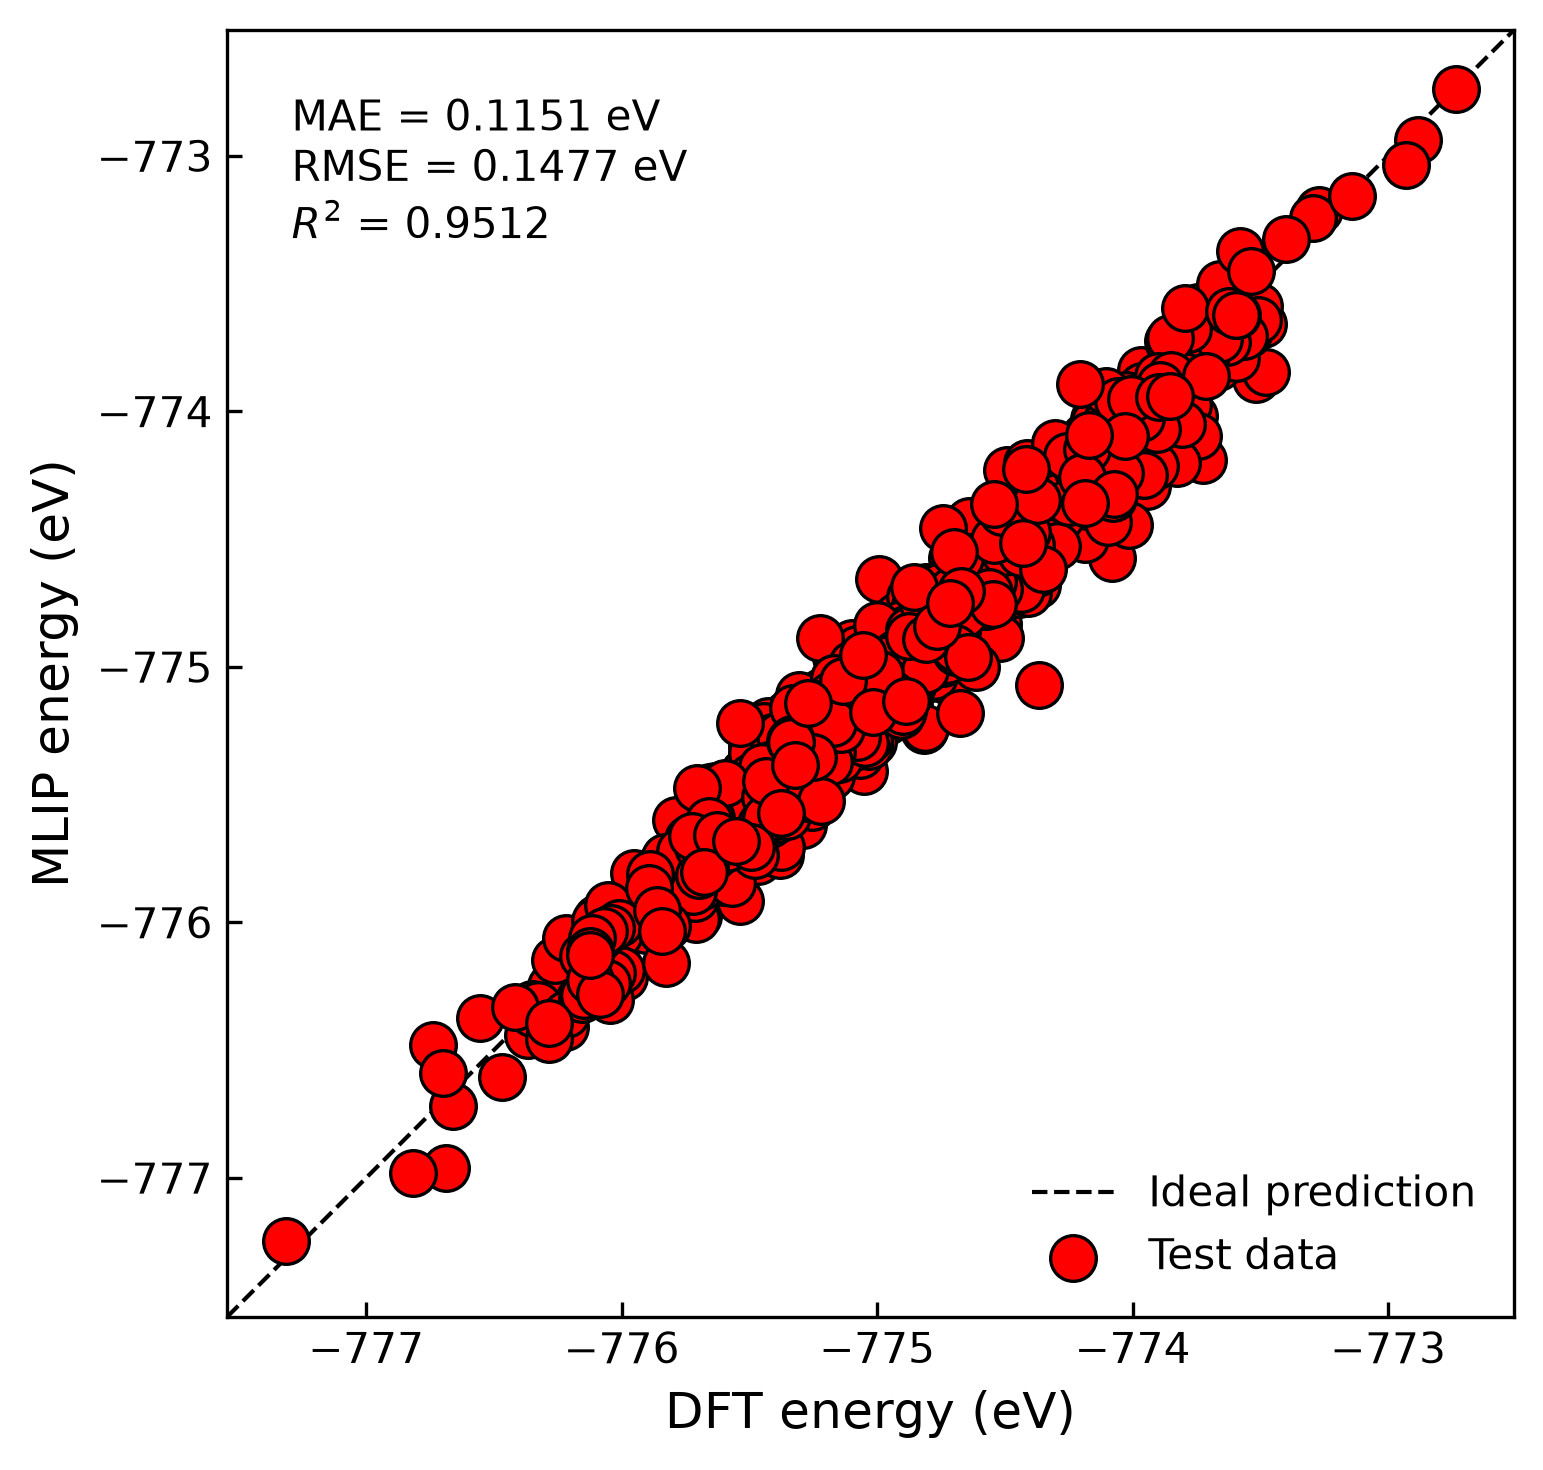

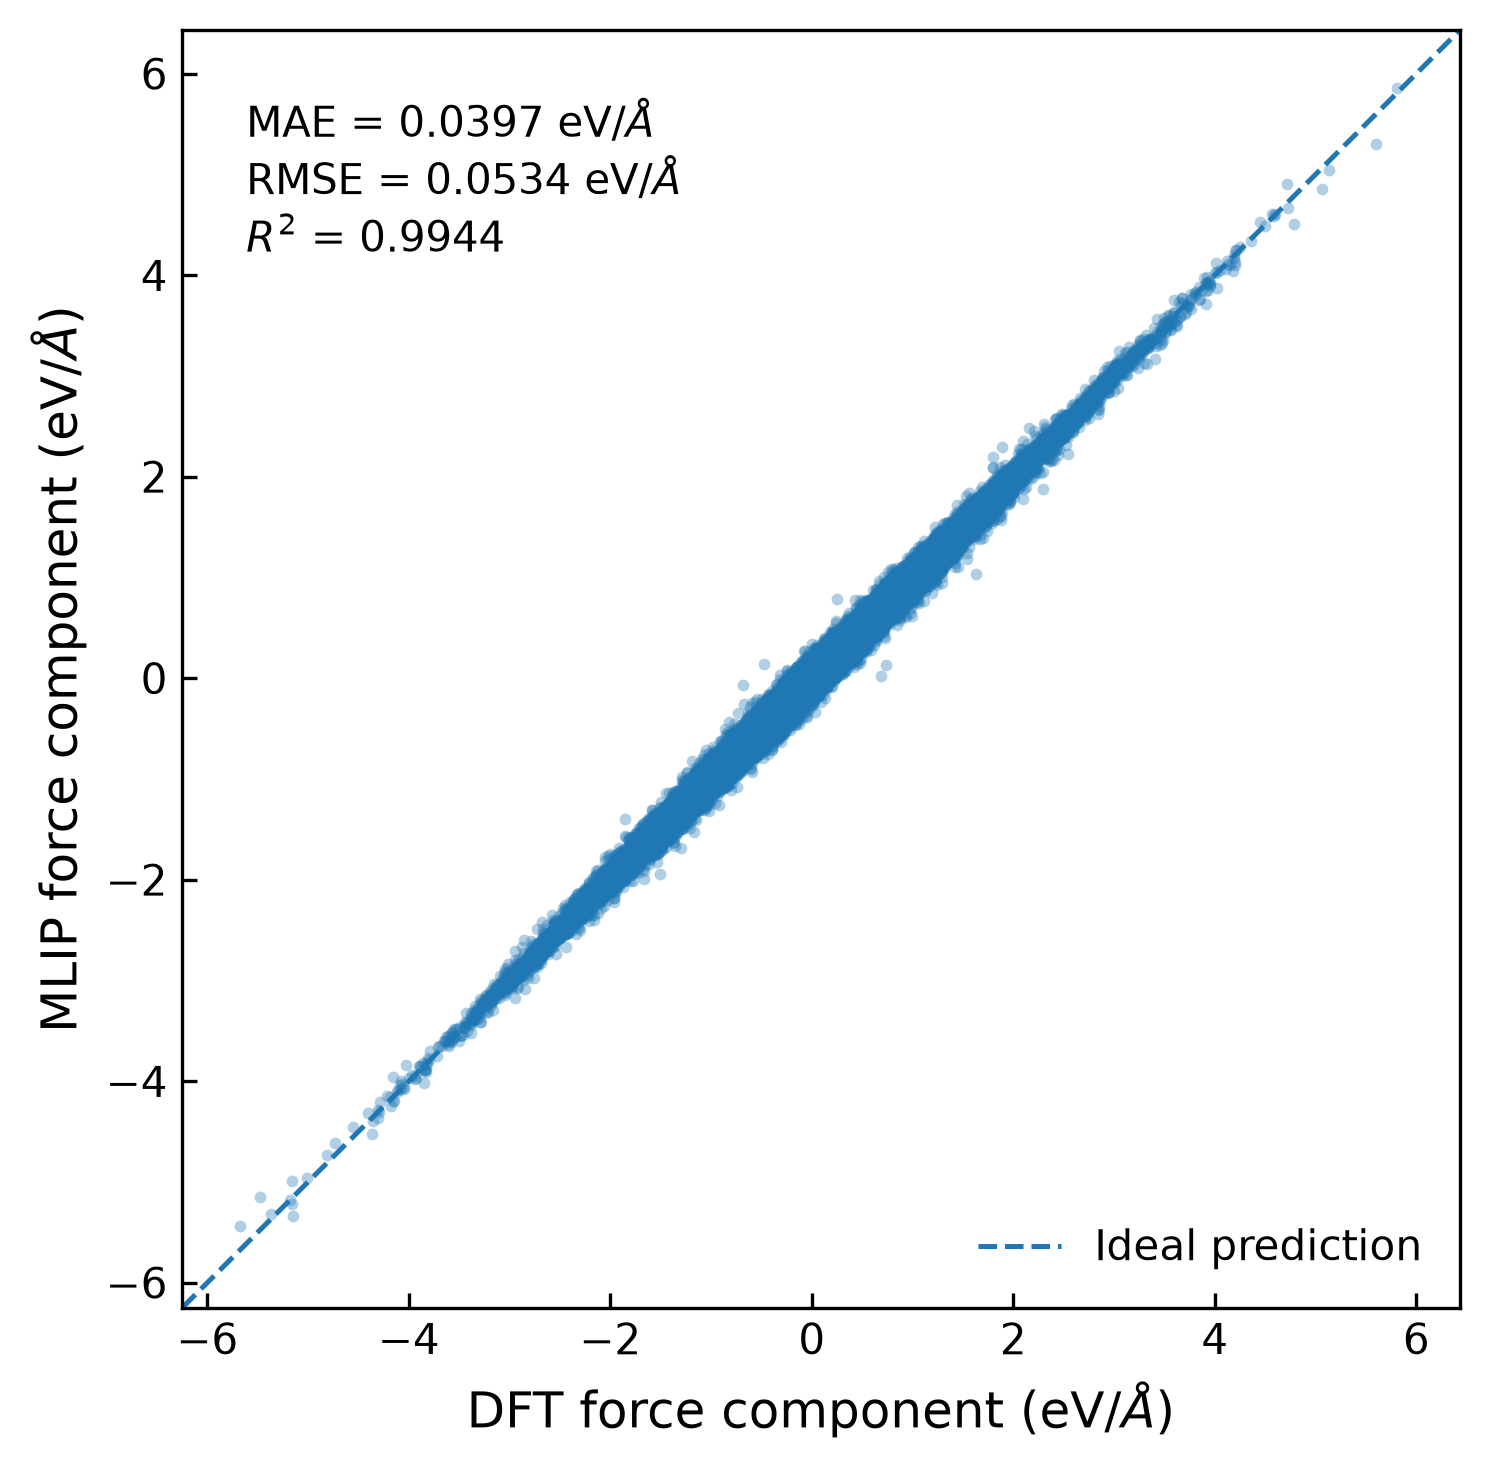

In [24]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Convert everything to NumPy arrays
# ============================================================
energy_dft = np.asarray(energy_dft, dtype=float).reshape(-1)
energy_mlip = np.asarray(energy_mlip, dtype=float).reshape(-1)

forces_dft = np.asarray(forces_dft, dtype=float)
forces_mlip = np.asarray(forces_mlip, dtype=float)

force_dft_flat = forces_dft.reshape(-1)
force_mlip_flat = forces_mlip.reshape(-1)


# ============================================================
# Helper functions
# ============================================================
def calculate_metrics(reference, prediction):
    reference = np.asarray(reference)
    prediction = np.asarray(prediction)

    error = prediction - reference

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))

    ss_res = np.sum(error**2)
    ss_tot = np.sum(
        (reference - np.mean(reference))**2
    )

    if ss_tot > 0:
        r_squared = 1.0 - ss_res / ss_tot
    else:
        r_squared = np.nan

    return mae, rmse, r_squared


def parity_limits(reference, prediction, padding_fraction=0.05):
    minimum = min(
        np.min(reference),
        np.min(prediction),
    )

    maximum = max(
        np.max(reference),
        np.max(prediction),
    )

    data_range = maximum - minimum

    if data_range == 0:
        data_range = max(abs(maximum), 1.0)

    padding = padding_fraction * data_range

    return minimum - padding, maximum + padding


# ============================================================
# Energy metrics
# ============================================================
energy_mae, energy_rmse, energy_r2 = calculate_metrics(
    energy_dft,
    energy_mlip,
)

energy_lower, energy_upper = parity_limits(
    energy_dft,
    energy_mlip,
)


# ============================================================
# Energy parity plot
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

energy_dft = np.asarray(energy_dft).flatten()
energy_mlip = np.asarray(energy_mlip).flatten()

lower = min(energy_dft.min(), energy_mlip.min())
upper = max(energy_dft.max(), energy_mlip.max())

padding = 0.05 * (upper - lower)
lower -= padding
upper += padding

plt.figure(figsize=(5.5, 5.0), dpi=300)

# Ideal line
plt.plot(
    [lower, upper],
    [lower, upper],
    "k--",
    linewidth=1.0,
    zorder=1,
    label="Ideal prediction",
)

# MLIP points
plt.scatter(
    energy_dft,
    energy_mlip,
    s=120,
    marker="o",
    color="red",
    edgecolor="black",
    linewidth=0.8,
    zorder=10,
    label="Test data",
)

plt.xlim(lower, upper)
plt.ylim(lower, upper)

plt.xlabel("DFT energy (eV)", fontsize=12)
plt.ylabel("MLIP energy (eV)", fontsize=12)

plt.legend(frameon=False)
plt.tick_params(direction="in")

plt.gca().set_aspect("equal", adjustable="box")


plt.text(
    0.05,
    0.95,
    (
        f"MAE = {energy_mae:.4f} eV\n"
        f"RMSE = {energy_rmse:.4f} eV\n"
        rf"$R^2$ = {energy_r2:.4f}"
    ),
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=10,
)

plt.legend(frameon=False)
plt.tick_params(direction="in")
plt.gca().set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig(
    "energy_parity.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()


# ============================================================
# Force metrics
# ============================================================
force_mae, force_rmse, force_r2 = calculate_metrics(
    force_dft_flat,
    force_mlip_flat,
)

force_lower, force_upper = parity_limits(
    force_dft_flat,
    force_mlip_flat,
)


# ============================================================
# Force parity plot
# ============================================================
plt.figure(figsize=(5.5, 5.0), dpi=300)

plt.scatter(
    force_dft_flat,
    force_mlip_flat,
    s=8,
    alpha=0.35,
    linewidths=0,
)

plt.plot(
    [force_lower, force_upper],
    [force_lower, force_upper],
    linestyle="--",
    linewidth=1.2,
    label="Ideal prediction",
)

plt.xlim(force_lower, force_upper)
plt.ylim(force_lower, force_upper)

plt.xlabel(
    r"DFT force component (eV/$\AA$)",
    fontsize=12,
)
plt.ylabel(
    r"MLIP force component (eV/$\AA$)",
    fontsize=12,
)

plt.text(
    0.05,
    0.95,
    (
        rf"MAE = {force_mae:.4f} eV/$\AA$"
        "\n"
        rf"RMSE = {force_rmse:.4f} eV/$\AA$"
        "\n"
        rf"$R^2$ = {force_r2:.4f}"
    ),
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=10,
)

plt.legend(frameon=False)
plt.tick_params(direction="in")
plt.gca().set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig(
    "force_parity.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()